## Import 

In [1]:
import os, scipy, glob, gc
import numpy as np
import matplotlib.pyplot as plt
import xrayutilities as xu
from tqdm import tqdm
import pandas as pd
import cv2 as cv
from scipy.signal import find_peaks
import seaborn as sns


from pyhectr import xrd_geom
from pyhectr import read_plot
from pyhectr import integration
from pyhectr import bragg_simulations as bs

%matplotlib widget

## Loading data for integration

In [5]:
#load data 

base_path = '/asap3/petra3/gpfs/p07/2022/data/11016526/raw/varex/'
InputDir = '/asap3/petra3/gpfs/p07/2022/data/11016526/raw/varex/'
OutputDir = '/asap3/petra3/gpfs/p07/2022/data/11016526/processed/processed_data/'
Experiments = sorted(next(os.walk(InputDir))[1])
Scan = Experiments[16]
img_path_pattern = InputDir + Scan + '/*[0-9].tif'


x0 = 1438  # center pixel, x
y0_init = 763 # center pixel, y
y0 = 2880 - y0_init
pix_size = 0.15
SDD = 1483.66 # mm
incidence_ang = 0.02
Lambda = 0.1680002615176152 # Angst, 73.8 keV


path_to_files = sorted(glob.glob(img_path_pattern))
ROIy = slice(0,2200) # vertical
ROIx = slice(0,2880) # horizontal
delta_ = xrd_geom.ROI_to_angle(ROIx, x0, pix_size, SDD)
gamma_ = xrd_geom.ROI_to_angle(ROIy, y0, pix_size, SDD)

chi_ = 0.
phi_ = 0.
mu_ = incidence_ang  # incidence_ang
mat = xu.materials.Al2O3# choosing material from xrayutilities library

# transformation = np.array([[1/2, 0, -1/2], [-1/2, 1/2, 0], [1, 1, 1]])  # leftovers for Pt(111)
# transformation_for_base_vectors = (np.linalg.inv(transformation)).T

a = np.array([4.1171, -2.377, 0])
b = np.array([0, 4.754, 0])
c = np.array([0, 0, 12.99])
pi = np.pi

B_1 = xrd_geom.set_reciprocal_cell_5(a, b, c, transformation_flag=False)
UB_inv = xrd_geom.UBinv(B_1, phi_, chi_, mu_)

data, omes_with_z = read_plot.read_P07_imgs_with_metadata(img_path_pattern, ROIx, ROIy)
omes = np.array([om[0] if len(om) > 0 else -1e5 for om in omes_with_z]).astype(float)
theta_ang = omes[::-1] 

## Theoretical scattering map

In [6]:
al2o3_cifName = 'sapphire.cif'
crystal = xu.materials.cif.CIFFile(al2o3_cifName)
al2o3 = xu.materials.Crystal("Al2O3", crystal.SGLattice())

In [6]:
max_index = 17
energy    = 73800  # eV 73221.6
out_of_plane = (0, 0, 1)

hkl_full = [(h,k,0)
             for h in range(-max_index, max_index+1)
             for k in range(-max_index, max_index+1)
             if ((h,k,0) != (0,0,0)) and bs.are_perpendicular((h,k,0), out_of_plane)]


In [8]:
peaks = []
hkl_full_filter = []
F2_arr = []
F_threshold = 1e-2
for hh, kk, ll in hkl_full:
    Q = al2o3.Q(hh, kk, ll)
    d = 2*np.pi/np.linalg.norm(Q)
    if d < 0.71 or d > 2.9:      # ignore d < 0.72 and d > 2.39 Å
        continue
    F2 = abs(al2o3.StructureFactor(Q, energy))**2
    if F2 < F_threshold:
        # print(F2)
        continue
    peaks.append(((hh, kk,ll), d.item(), F2.item()))
    F2_arr.append(F2.item())
    hkl_full_filter.append([hh, kk, ll])

# sort by decreasing d (or increasing 2θ)
peaks.sort(key=lambda x: -x[1])

In [9]:
len(peaks)

36

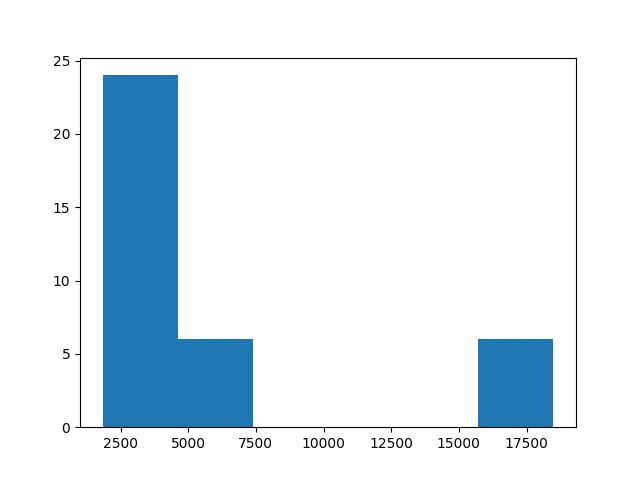

In [10]:
plt.figure()
plt.hist(F2_arr, bins='sqrt')
plt.show()

In [11]:
d_values = []
labels = []
tol = 1e-4
for hkl, d, F2 in peaks:
    if not any(abs(d - d0) < tol for d0 in d_values):
        d_values.append(d)
        labels.append(hkl)


In [12]:
d_values

[2.3803500000000013,
 1.3742957132655265,
 1.1901750000000006,
 0.8996877333275144,
 0.7934500000000004]

  6%|▌         | 2/36 [00:00<00:05,  5.80it/s]

XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inpl

 11%|█         | 4/36 [00:00<00:03,  8.99it/s]

XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inpl

 22%|██▏       | 8/36 [00:00<00:02, 11.45it/s]

...

XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inpl

 94%|█████████▍| 34/36 [00:02<00:00, 11.96it/s]

XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)


100%|██████████| 36/36 [00:03<00:00, 11.62it/s]


XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)
XU.HXRD: some position is perpendicular to ndir-reference direction (might be inplane or unreachable)


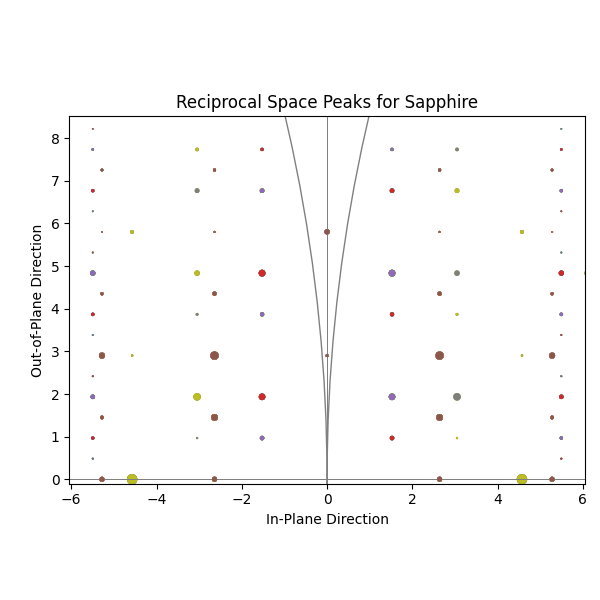

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ttmax = 180  # Maximum theta-2theta angle

set_all_neg = set()
set_all_arr_neg = []
peak_positions = []

for (hh, kk, ll) in tqdm(hkl_full_filter):
    Q = al2o3.Q(hh, kk, ll)
    h_al2o3 = xu.HXRD(
        Q,  # In-plane direction
        al2o3.Q(*out_of_plane),  # Out-of-plane direction
    )
    h_al2o3.energy = energy  # Example energy in eV
    ax, h_, peak_data = bs.show_reciprocal_space_plane(
        al2o3,
        h_al2o3,
        ttmax=ttmax,
        ax=ax,  # Re-use the same axes
        label=f"Al2O3 ({hh},{kk},{ll})",
        projection='polar',
        # projection = 'perpendicular',
        scalef = 200,
        sf_threshold= 6e-9, 
        show_legend=False,
        q_max = 12.1
    )
    peak_data_filtered = bs.filter_peaks_in_plot_range(
                                            peak_data,
                                            xlim=(-6.05, 6.05),
                                            ylim=(-0.01, 8.51)
                                            )
    peak_positions.append(peak_data_filtered)

# for d, hkl in zip(d_values, labels):
#     radius = 2 * np.pi / d
#     circle1 = plt.Circle((0, 0), radius, color='r', fill=False, lw=0.8)
#     ax.add_patch(circle1)
#     ax.text(0, radius + 0.1, f'd = {d:.4f} Å {hkl}', color='blue', fontsize=9, ha='center')

# Customize the plot (optional)
ax.set_title("Reciprocal Space Peaks for Sapphire")
ax.set_xlabel("In-Plane Direction")
ax.set_ylabel("Out-of-Plane Direction")
ax.set_xlim(-6.05, 6.05)
ax.set_ylim(-0.1, 8.51)

ax.set_aspect(1)
# Display the plot
#plt.show()


In [14]:
len(peak_positions)

36

In [15]:
all_records = []
for p_p in peak_positions:
    all_records.extend(bs.peak_dict_to_records(p_p))

total = pd.DataFrame(all_records)#.sort_values(by=['x', 'y'])

len(total)

828

In [16]:
# total.to_csv('Sapphire_peaks_P07.csv')

In [17]:
#total_filter = total.drop_duplicates(subset=['x', 'y'], keep='first')
total_filter = total.drop_duplicates(subset='qvec', keep='first')
total_filter = total_filter.drop_duplicates(subset='hkl', keep='first')

total_filter = total_filter.sort_values(by=['x', 'y'])

len(total_filter)

199

In [18]:
aggregated_peak_data = {
    'x': total_filter['x'].to_numpy(),
    'y': total_filter['y'].to_numpy(),
    'hkl': total_filter['hkl'].to_numpy(),
    'qvec': total_filter['qvec'].to_numpy(),
    'angles': total_filter['angles'].to_numpy(),
}

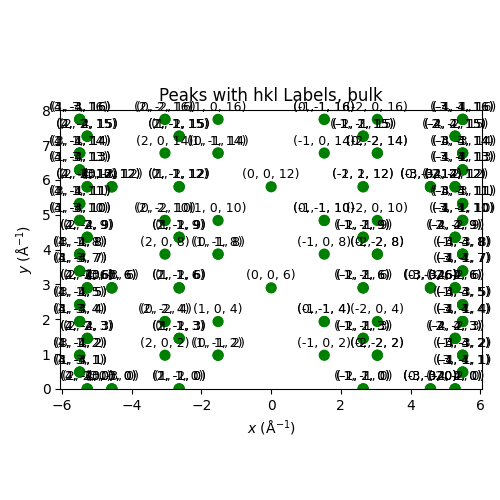

In [19]:
ax, scatter = bs.plot_peak_data_with_labels(aggregated_peak_data, 
                                         # projection='not perpendicular', 
                                         #maxqout=0.5, 
                                         scalef=50, color='g', 
                                         annotate_offset=(0, 4),
                                         title="Peaks with hkl Labels, bulk")


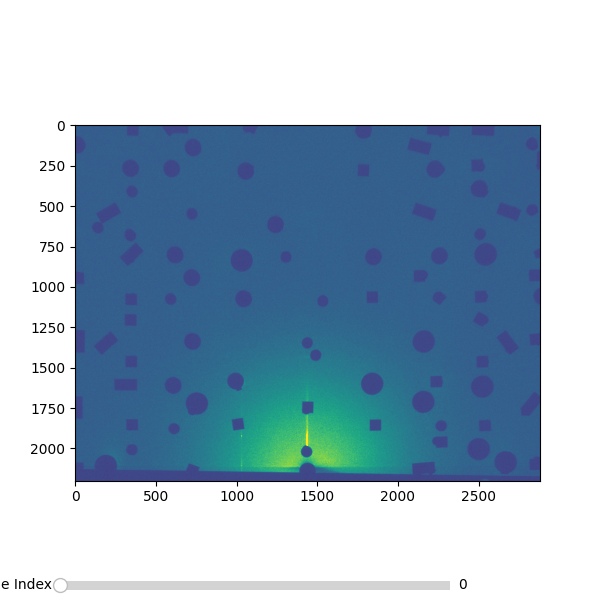

In [20]:
read_plot.image_slider(data, vmax1=250, fig_size=(6, 6))

## $th_0$ search

### Bragg peaks mode

In [21]:
# Bragg peak: -102
point_pxl_1 = np.argwhere( (data[238:241, 1700:2050, 1005:1065]< 20) | (data[238:241, 1700:2050, 1005:1065]> 1500) )
point_pxl_1[:, 2] = point_pxl_1[:, 2] + 1005
point_pxl_1[:, 1] = point_pxl_1[:, 1] + 1700
point_pxl_1[:, 0] = point_pxl_1[:, 0] + 238
point_pxl_1[::1].shape, point_pxl_1

((6227, 3),
 array([[ 238, 1755, 1032],
        [ 238, 1756, 1032],
        [ 238, 1757, 1032],
        ...,
        [ 240, 1965, 1033],
        [ 240, 1966, 1031],
        [ 240, 1966, 1032]]))

In [22]:
# Bragg peak: 104
point_pxl_2 = np.argwhere( (data[255:261, 1480:1750, 1815:1870]< 20) | (data[255:261, 1480:1750, 1815:1870]> 1500) )
point_pxl_2[:, 2] = point_pxl_2[:, 2] + 1815
point_pxl_2[:, 1] = point_pxl_2[:, 1] + 1480
point_pxl_2[:, 0] = point_pxl_2[:, 0] + 255
point_pxl_2[::1].shape, point_pxl_2

((40843, 3),
 array([[ 255, 1480, 1818],
        [ 255, 1509, 1821],
        [ 255, 1514, 1837],
        ...,
        [ 260, 1666, 1850],
        [ 260, 1666, 1852],
        [ 260, 1667, 1835]]))

In [23]:
# Bragg peak: 1-18
point_pxl_3 = np.argwhere( (data[35:44, 1000:1200, 1826:1854]< 20) | (data[35:44, 1000:1200, 1826:1854]> 1500) )
point_pxl_3[:, 2] = point_pxl_3[:, 2] + 1826
point_pxl_3[:, 1] = point_pxl_3[:, 1] + 1000
point_pxl_3[:, 0] = point_pxl_3[:, 0] + 35
point_pxl_3[::1].shape, point_pxl_3

((17830, 3),
 array([[  35, 1000, 1826],
        [  35, 1000, 1848],
        [  35, 1001, 1829],
        ...,
        [  43, 1195, 1840],
        [  43, 1198, 1827],
        [  43, 1199, 1850]]))

In [24]:
point_pxl_1 = point_pxl_1[::1]
point_pxl_2 = point_pxl_2[::4]
point_pxl_3 = point_pxl_3[::3]
point_pxl_1.shape, point_pxl_2.shape, point_pxl_3.shape

((6227, 3), (10211, 3), (5944, 3))

In [25]:
# rods (parametrized)
braggs = [
    {"points": point_pxl_1, "hk": (-1, 0), "l": 2, "wl": 1.0},
    {"points": point_pxl_2, "hk": (1, 0), "l": 4, "wl": 1.0},
    {"points": point_pxl_3, "hk": (1, -1), "l": 8, "wl": 1.0},
]

In [26]:
keep_frac = 0.10  # "use best 10% of pixels" 

# coarse
theta0_start, theta0_stop, theta0_step = -181, 181, 1
theta_grid = np.arange(theta0_start, theta0_stop, theta0_step)
theta0_best, costs_coarse = bs.scan_theta(theta_grid, braggs, keep_frac, 
                                       theta_ang, UB_inv, Lambda, 
                                       x0, y0, pix_size, SDD)

theta0_best

29

In [27]:
# fine around coarse minimum
theta0_start_fine = theta0_best - theta0_step - 1
theta0_stop_fine  = theta0_best + theta0_step + 1
theta0_step_fine  = 0.001
theta_grid_fine = np.arange(theta0_start_fine, theta0_stop_fine, theta0_step_fine)
theta0_best_fine, costs_fine = bs.scan_theta(theta_grid_fine, braggs, keep_frac, 
                                          theta_ang, UB_inv, Lambda,
                                          x0, y0, pix_size, SDD)

theta0_best, theta0_best_fine

(29, 29.07100000000253)

In [28]:
# coarse 

keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_start, theta0_stop, theta0_step = -181, 181, 0.1
theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(theta_grid_fracs, braggs, keep_frac,
                                theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD)
    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])
    print(f"keep_frac={keep_frac:0.2f}  theta0_best={th_best:0.4f} min_cost={costs.min():0.5f} frac01of{keep_frac}_cost={float(frac01_cost):0.6f} ")

keep_frac=0.01  theta0_best=28.8000 min_cost=0.00058 frac01of0.01_cost=0.114202 
keep_frac=0.05  theta0_best=28.9000 min_cost=0.00235 frac01of0.05_cost=0.121863 
keep_frac=0.10  theta0_best=29.0000 min_cost=0.00447 frac01of0.1_cost=0.128264 
keep_frac=0.20  theta0_best=29.1000 min_cost=0.00901 frac01of0.2_cost=0.138952 
keep_frac=0.40  theta0_best=29.3000 min_cost=0.02265 frac01of0.4_cost=0.158944 
keep_frac=0.60  theta0_best=29.3000 min_cost=0.04855 frac01of0.6_cost=0.185607 
keep_frac=0.80  theta0_best=29.4000 min_cost=0.08964 frac01of0.8_cost=0.225835 
keep_frac=0.95  theta0_best=29.3000 min_cost=0.12916 frac01of0.95_cost=0.264881 


In [29]:
# fine

keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_start, theta0_stop, theta0_step = theta0_best_fine-1, theta0_best_fine+1, 0.0005
theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(theta_grid_fracs, braggs, keep_frac,
                                theta_ang, UB_inv, Lambda, x0, y0, 
                                pix_size, SDD)
    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])
    print(f"keep_frac={keep_frac:0.2f}  theta0_best={th_best:0.4f} min_cost={costs.min():0.5f} frac01of{keep_frac}_cost={float(frac01_cost):0.6f} ")

keep_frac=0.01  theta0_best=29.0645 min_cost=0.00056 frac01of0.01_cost=0.000577 
keep_frac=0.05  theta0_best=28.9660 min_cost=0.00233 frac01of0.05_cost=0.002352 
keep_frac=0.10  theta0_best=29.0715 min_cost=0.00446 frac01of0.1_cost=0.004478 
keep_frac=0.20  theta0_best=29.1230 min_cost=0.00898 frac01of0.2_cost=0.009002 
keep_frac=0.40  theta0_best=29.3445 min_cost=0.02265 frac01of0.4_cost=0.022673 
keep_frac=0.60  theta0_best=29.3310 min_cost=0.04853 frac01of0.6_cost=0.048554 
keep_frac=0.80  theta0_best=29.2735 min_cost=0.08963 frac01of0.8_cost=0.089639 
keep_frac=0.95  theta0_best=29.2460 min_cost=0.12911 frac01of0.95_cost=0.129159 


In [30]:
keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_start, theta0_stop, theta0_step = theta0_best_fine-1, theta0_best_fine+1, 0.0005
theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(
        theta_grid_fracs, braggs, keep_frac,
        theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD
    )

    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])

    print(
        f"keep_frac={keep_frac:0.2f}  "
        f"theta0_best={th_best:0.4f}  "
        f"min_cost={costs.min():0.5f}  "
        f"frac01_cost={frac01_cost:0.5f}"
    )

    bs.report_best_fraction(
        th_best, braggs, keep_frac,
        theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD,
        mode='median'   # or 'mean'
    )

    print()

keep_frac=0.01  theta0_best=29.0645  min_cost=0.00056  frac01_cost=0.00058
   rod1 len=63/6227 best_hkl=(-1.00122, 0.00203, 2.00055) median_hkl=(-1.00113, 0.00187, 2.00055) median_L2=0.000095
   rod2 len=103/10211 best_hkl=(0.99791, -0.00034, 4.00489) median_hkl=(0.99999, 0.00012, 3.99710) median_L2=0.000267
   rod3 len=60/5944 best_hkl=(1.00396, -0.99727, 8.00176) median_hkl=(0.99903, -0.99980, 8.00176) median_L2=0.000197

keep_frac=0.05  theta0_best=28.9660  min_cost=0.00233  frac01_cost=0.00235
   rod1 len=312/6227 best_hkl=(-0.99964, -0.00114, 2.00056) median_hkl=(-1.00219, 0.00359, 2.00055) median_L2=0.000563
   rod2 len=511/10211 best_hkl=(0.99637, -0.00220, 3.99710) median_hkl=(0.99920, 0.00186, 3.99711) median_L2=0.001131
   rod3 len=298/5944 best_hkl=(1.00298, -0.99827, 8.00176) median_hkl=(0.99676, -1.00222, 8.00176) median_L2=0.000641

keep_frac=0.10  theta0_best=29.0715  min_cost=0.00446  frac01_cost=0.00448
   rod1 len=623/6227 best_hkl=(-1.00115, 0.00189, 2.00055) median_

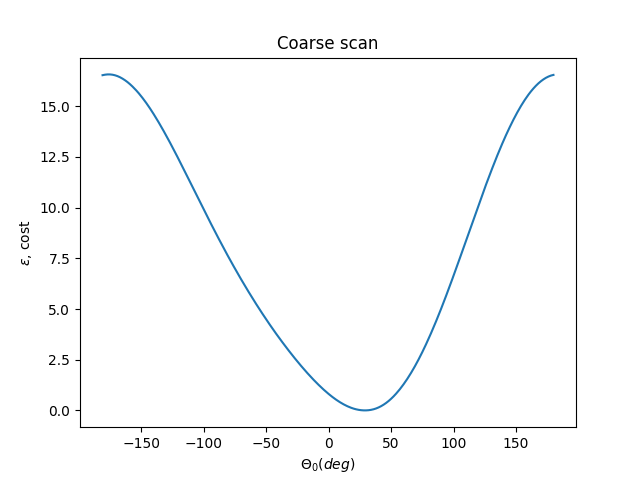

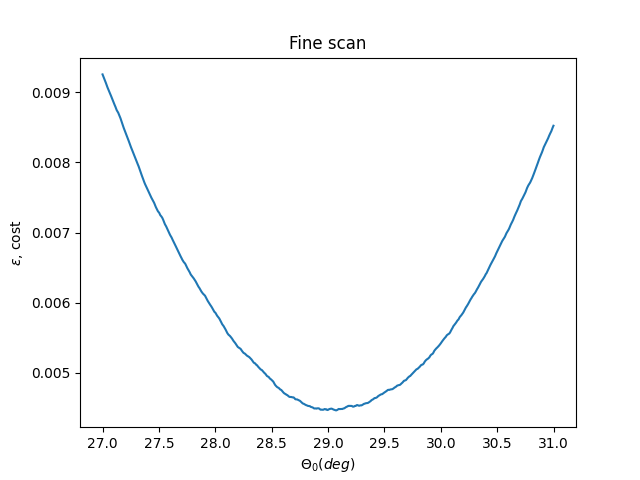

In [31]:
plt.figure()
plt.plot(theta_grid, costs_coarse)
plt.title("Coarse scan")
plt.xlabel('$ \Theta_{0} (deg) $')
plt.ylabel('$ \epsilon $, cost')
plt.show()

plt.figure()
plt.plot(theta_grid_fine, costs_fine)
plt.xlabel('$ \Theta_{0} (deg) $')
plt.ylabel('$ \epsilon $, cost')
plt.title("Fine scan")
plt.show()

### CTRs mode

In [32]:
#Rod: -1-1L
pixel_coord_22 = np.array(np.argwhere( (data[45:118, :, 725:770]>=160) ))# | (data[45:118, :, 725:770]<1) ))
pixel_coord_22[:, 2] = pixel_coord_22[:, 2] + 725
pixel_coord_22[:, 0] = pixel_coord_22[:, 0] + 45
pixel_coord_22[:].shape, pixel_coord_22

((17552, 3),
 array([[  46,    1,  759],
        [  46,    1,  760],
        [  46,    1,  761],
        ...,
        [ 117, 2102,  740],
        [ 117, 2102,  741],
        [ 117, 2102,  742]]))

In [33]:
#Rod: 11L
pixel_coord_11 = np.array(np.argwhere( (data[135:205, :, 2112:2169]>=160) ))
pixel_coord_11[:, 2] = pixel_coord_11[:, 2] + 2112
pixel_coord_11[:, 0] = pixel_coord_11[:, 0] + 135
pixel_coord_11[:].shape, pixel_coord_11

((14967, 3),
 array([[ 135, 1777, 2139],
        [ 135, 1777, 2140],
        [ 135, 1778, 2138],
        ...,
        [ 204,   34, 2113],
        [ 204,   35, 2112],
        [ 204,   36, 2112]]))

In [34]:
#Rod: 30L
pixel_coord_33 = np.array(np.argwhere( (data[18:60, : , 2635:2675]>=110) ))
pixel_coord_33[:, 2] = pixel_coord_33[:, 2] + 2635
pixel_coord_33[:, 0] = pixel_coord_33[:, 0] + 18
pixel_coord_33[:].shape, pixel_coord_33

((12594, 3),
 array([[  18, 2159, 2657],
        [  18, 2159, 2658],
        [  18, 2159, 2659],
        ...,
        [  56,  141, 2651],
        [  56,  142, 2648],
        [  56,  142, 2649]]))

In [35]:
#Rod: 22L
pixel_coord_44 = np.array(np.argwhere( (data[142:177, :, 2835:2865]>=100) ))
pixel_coord_44[:, 2] = pixel_coord_44[:, 2] + 2835
pixel_coord_44[:, 0] = pixel_coord_44[:, 0] + 142
pixel_coord_44[:].shape, pixel_coord_44

((14628, 3),
 array([[ 142, 1361, 2852],
        [ 142, 1361, 2854],
        [ 142, 1363, 2844],
        ...,
        [ 176,   47, 2847],
        [ 176,   48, 2844],
        [ 176,   48, 2845]]))

In [36]:
point_pxl_1 = pixel_coord_11[::2]
point_pxl_2 = pixel_coord_22[::2]
point_pxl_3 = pixel_coord_33[::2]
point_pxl_4 = pixel_coord_44[::2]
point_pxl_1.shape, point_pxl_2.shape, point_pxl_3.shape, point_pxl_4.shape

((7484, 3), (8776, 3), (6297, 3), (7314, 3))

In [37]:
rods_rodmode = [
    {"points": point_pxl_1, "hk": (1, 1), "l": None, "wl": 0.0},
    {"points": point_pxl_2, "hk": (-1, -1), "l": None, "wl": 0.0},
    {"points": point_pxl_3, "hk": (3, 0), "l": None, "wl": 0.0},
    {"points": point_pxl_4, "hk": (2, 2), "l": None, "wl": 0.0},
]

### Peaks, hexagonal symmetry 

In [38]:
theta_grid_coarse = np.arange(-180, 180, 1)

hk_families = [bs.hexagonal_hk_symmetry(*r["hk"]) for r in rods_rodmode]
hk_families

[[(1, 1), (-1, 2), (-2, 1), (-1, -1), (1, -2), (2, -1)],
 [(-1, -1), (1, -2), (2, -1), (1, 1), (-1, 2), (-2, 1)],
 [(3, 0), (0, 3), (-3, 3), (-3, 0), (0, -3), (3, -3)],
 [(2, 2), (-2, 4), (-4, 2), (-2, -2), (2, -4), (4, -2)]]

In [39]:
df_sym = bs.brute_force_hk_symmetry_search(
    rods=rods_rodmode,
    keep_frac=0.10,
    theta_grid_coarse=theta_grid_coarse,
    omes_ang=theta_ang, UBinv=UB_inv, Lambda=Lambda,
    x0=x0, y0=y0, pix_size=pix_size, SDD=SDD,
    lock_first=True,
    skip_duplicate_hk=False,
    hk_families=hk_families,
)

#df_sym.head(20)

216it [04:17,  1.19s/it]


In [40]:
df_sym.head(20)

,theta0_coarse,cost_coarse,hk1,hk2,hk3,hk4
0,89.0,0.000054,"(1, 1)","(-1, -1)","(3, 0)","(2, 2)"
1,38.0,4.375683,"(1, 1)","(-2, 1)","(3, -3)","(4, -2)"
2,95.0,4.397949,"(1, 1)","(1, -2)","(3, 0)","(2, 2)"
3,83.0,4.405638,"(1, 1)","(-2, 1)","(3, 0)","(2, 2)"
4,142.0,4.545879,"(1, 1)","(1, -2)","(0, 3)","(-2, 4)"
5,77.0,6.749751,"(1, 1)","(-1, -1)","(3, -3)","(2, 2)"
6,34.0,6.776248,"(1, 1)","(-1, 2)","(3, -3)","(4, -2)"
7,145.0,6.828352,"(1, 1)","(2, -1)","(0, 3)","(-2, 4)"
8,47.0,7.540710,"(1, 1)","(-1, -1)","(3, -3)","(4, -2)"
9,-91.0,7.955375,"(1, 1)","(1, 1)","(-3, 0)","(-2, -2)"


In [41]:
best = df_sym.iloc[0]
best_hks = [best[f"hk{i}"] for i in range(1, len(rods_rodmode) + 1)]
best_theta0 = best["theta0_coarse"]

print("best_theta0 =", best_theta0)
print("best_hks =", best_hks)


best_theta0 = 89.0
best_hks = [(1, 1), (-1, -1), (3, 0), (2, 2)]


### Peaks symmetry from scattering table, general case

In [42]:
#  #general case
hk_familie_from_table = []
for r in rods_rodmode: 
    hk_familie_from_table.append(bs.extract_hk_symmetry_from_table(total, r['hk'][0], r['hk'][1], l=None, \
                    key_cols=["x"], return_rows=False))


hk_familie_from_table

[[(-2, 1), (-1, -1), (-1, 2), (1, -2), (1, 1), (2, -1)],
 [(-2, 1), (-1, -1), (-1, 2), (1, -2), (1, 1), (2, -1)],
 [(-3, 0), (-3, 3), (0, -3), (0, 3), (3, -3), (3, 0)],
 [(-4, 2), (-2, -2), (-2, 4), (2, -4), (2, 2), (4, -2)]]

In [43]:
df_sym = bs.brute_force_hk_symmetry_search(
    rods=rods_rodmode,
    keep_frac=0.10,
    theta_grid_coarse=theta_grid_coarse,
    omes_ang=theta_ang, UBinv=UB_inv, Lambda=Lambda,
    x0=x0, y0=y0, pix_size=pix_size, SDD=SDD,
    lock_first=True,
    skip_duplicate_hk=False,
    hk_families=hk_familie_from_table,
)

#df_sym.head(20)

216it [04:17,  1.19s/it]


In [44]:
df_sym.head(20)

,theta0_coarse,cost_coarse,hk1,hk2,hk3,hk4
0,89.0,0.000054,"(1, 1)","(-1, -1)","(3, 0)","(2, 2)"
1,38.0,4.375683,"(1, 1)","(-2, 1)","(3, -3)","(4, -2)"
2,95.0,4.397949,"(1, 1)","(1, -2)","(3, 0)","(2, 2)"
3,83.0,4.405638,"(1, 1)","(-2, 1)","(3, 0)","(2, 2)"
4,142.0,4.545879,"(1, 1)","(1, -2)","(0, 3)","(-2, 4)"
5,77.0,6.749751,"(1, 1)","(-1, -1)","(3, -3)","(2, 2)"
6,34.0,6.776248,"(1, 1)","(-1, 2)","(3, -3)","(4, -2)"
7,145.0,6.828352,"(1, 1)","(2, -1)","(0, 3)","(-2, 4)"
8,47.0,7.540710,"(1, 1)","(-1, -1)","(3, -3)","(4, -2)"
9,-91.0,7.955375,"(1, 1)","(1, 1)","(-3, 0)","(-2, -2)"


In [45]:
best = df_sym.iloc[0]
best_hks = [best[f"hk{i}"] for i in range(1, len(rods_rodmode) + 1)]
best_theta0 = best["theta0_coarse"]

print("best_theta0 =", best_theta0)
print("best_hks =", best_hks)
#print("best_cost =", best["cost_fine"])

best_theta0 = 89.0
best_hks = [(1, 1), (-1, -1), (3, 0), (2, 2)]


### Refinement with proper labelling 

In [46]:
rods_rodmode = [
    {"points": point_pxl_1, "hk": best_hks[0], "l": None, "wl": 0.0},
    {"points": point_pxl_2, "hk": best_hks[1], "l": None, "wl": 0.0},
    {"points": point_pxl_3, "hk": best_hks[2], "l": None, "wl": 0.0},
    {"points": point_pxl_4, "hk": best_hks[3], "l": None, "wl": 0.0},
]

In [47]:
# coarse search
theta0_start_coarse, theta0_stop_coarse, theta0_step = -181, 181, 1

theta_grid_coarse = np.arange(theta0_start_coarse, theta0_stop_coarse, theta0_step)
theta0_best, costs_coarse = bs.scan_theta(theta_grid_coarse, rods_rodmode, keep_frac, 
                                          theta_ang, UB_inv, Lambda,
                                          x0, y0, pix_size, SDD)

# fine around coarse minimum
theta0_start_fine = theta0_best - theta0_step 
theta0_stop_fine  = theta0_best + theta0_step
theta0_step_fine  = 0.0001
theta_grid_fine = np.arange(theta0_start_fine, theta0_stop_fine, theta0_step_fine)
theta0_best_fine, costs_fine = bs.scan_theta(theta_grid_fine, rods_rodmode, keep_frac, 
                                          theta_ang, UB_inv, Lambda,
                                          x0, y0, pix_size, SDD)

theta0_best, theta0_best_fine

(89, 88.85960000002854)

In [48]:
# grid report 
# coarse

keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_start, theta0_stop, theta0_step = -180, 180, 1

theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(theta_grid_fracs, rods_rodmode, keep_frac,
                                theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD)
    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])
    print(f"keep_frac={keep_frac:0.2f}  theta0_best={th_best:0.4f} min_cost={costs.min():0.5f} frac01of{keep_frac}_cost={float(frac01_cost):0.6f} ")

keep_frac=0.01  theta0_best=89.0000 min_cost=0.00001 frac01of0.01_cost=1.515133 
keep_frac=0.05  theta0_best=89.0000 min_cost=0.00003 frac01of0.05_cost=1.590156 
keep_frac=0.10  theta0_best=89.0000 min_cost=0.00005 frac01of0.1_cost=1.607745 
keep_frac=0.20  theta0_best=89.0000 min_cost=0.00011 frac01of0.2_cost=1.618500 
keep_frac=0.40  theta0_best=89.0000 min_cost=0.00021 frac01of0.4_cost=1.631780 
keep_frac=0.60  theta0_best=89.0000 min_cost=0.00033 frac01of0.6_cost=1.641834 
keep_frac=0.80  theta0_best=89.0000 min_cost=0.00046 frac01of0.8_cost=1.650731 
keep_frac=0.95  theta0_best=89.0000 min_cost=0.00056 frac01of0.95_cost=1.656977 


In [49]:
# grid report 
# fine

keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_start, theta0_stop, theta0_step = theta0_best_fine-1, theta0_best_fine+1, 0.0001
theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(theta_grid_fracs, rods_rodmode, keep_frac,
                                theta_ang, UB_inv, Lambda, x0, y0, 
                                pix_size, SDD)
    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])
    print(f"keep_frac={keep_frac:0.2f}  theta0_best={th_best:0.4f} min_cost={costs.min():0.5f} frac01of{keep_frac}_cost={float(frac01_cost):0.6f} ")

keep_frac=0.01  theta0_best=88.8573 min_cost=0.00000 frac01of0.01_cost=0.000003 
keep_frac=0.05  theta0_best=88.8330 min_cost=0.00001 frac01of0.05_cost=0.000015 
keep_frac=0.10  theta0_best=88.8308 min_cost=0.00002 frac01of0.1_cost=0.000029 
keep_frac=0.20  theta0_best=88.8402 min_cost=0.00005 frac01of0.2_cost=0.000060 
keep_frac=0.40  theta0_best=88.8665 min_cost=0.00011 frac01of0.4_cost=0.000126 
keep_frac=0.60  theta0_best=88.8719 min_cost=0.00018 frac01of0.6_cost=0.000204 
keep_frac=0.80  theta0_best=88.8579 min_cost=0.00026 frac01of0.8_cost=0.000290 
keep_frac=0.95  theta0_best=88.8596 min_cost=0.00032 frac01of0.95_cost=0.000363 


In [50]:
keep_fracs = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

theta0_best_fine = 88.8402

theta0_start, theta0_stop, theta0_step = theta0_best_fine-1, theta0_best_fine+1, 0.0005
theta_grid_fracs = np.arange(theta0_start, theta0_stop, theta0_step)

for keep_frac in keep_fracs:
    th_best, costs = bs.scan_theta(
        theta_grid_fracs, rods_rodmode, keep_frac,
        theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD
    )

    m_cost = max(1, int(np.ceil(len(costs) * 0.1)))
    frac01_cost = np.mean(np.partition(costs, m_cost - 1)[:m_cost])

    print(
        f"keep_frac={keep_frac:0.2f}  "
        f"theta0_best={th_best:0.4f}  "
        f"min_cost={costs.min():0.5f}  "
        f"frac01_cost={frac01_cost:0.5f}"
    )

    bs.report_best_fraction(
        th_best, rods_rodmode, keep_frac,
        theta_ang, UB_inv, Lambda, x0, y0, pix_size, SDD,
        mode='median'   # or 'mean'
    )

    print()

keep_frac=0.01  theta0_best=88.8572  min_cost=0.00000  frac01_cost=0.00000
   rod1 len=75/7484 best_hkl=(0.99998, 1.00001, 14.43706) median_hkl=(1.00014, 1.00015, 10.20435) median_L2=0.000000
   rod2 len=88/8776 best_hkl=(-1.00011, -1.00000, 8.71606) median_hkl=(-1.00021, -1.00022, 4.91977) median_L2=0.000001
   rod3 len=63/6297 best_hkl=(2.99993, -0.00002, 15.17713) median_hkl=(3.00024, 0.00009, 7.75454) median_L2=0.000000
   rod4 len=74/7314 best_hkl=(1.99987, 2.00005, 7.26710) median_hkl=(2.00022, 2.00022, 3.91343) median_L2=0.000001

keep_frac=0.05  theta0_best=88.8407  min_cost=0.00001  frac01_cost=0.00001
   rod1 len=375/7484 best_hkl=(0.99995, 0.99984, 7.98447) median_hkl=(0.99998, 0.99999, 8.61444) median_L2=0.000002
   rod2 len=439/8776 best_hkl=(-1.00011, -1.00005, 5.30419) median_hkl=(-1.00017, -1.00005, 5.26538) median_L2=0.000003
   rod3 len=315/6297 best_hkl=(2.99998, 0.00005, 9.19006) median_hkl=(3.00013, -0.00015, 5.76092) median_L2=0.000002
   rod4 len=366/7314 best_hk

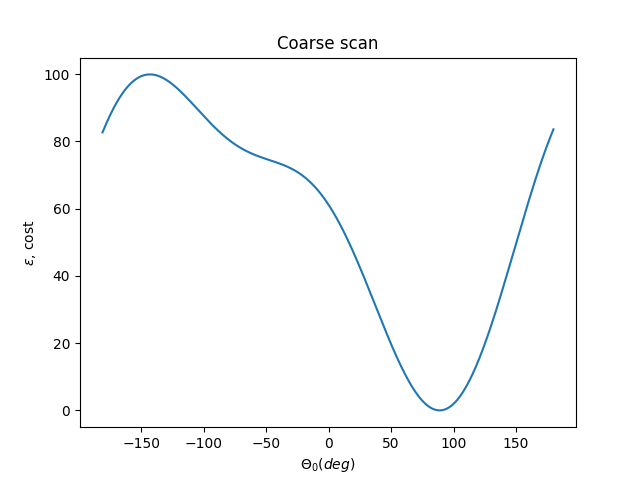

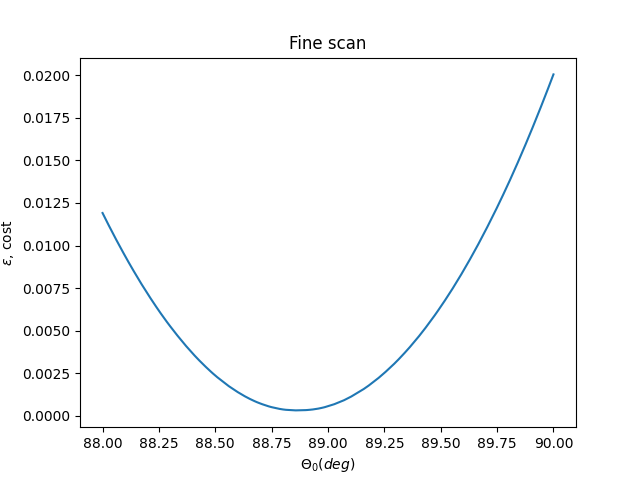

In [51]:
plt.figure()
plt.plot(theta_grid, costs_coarse)
plt.title("Coarse scan")
plt.xlabel('$ \Theta_{0} (deg) $')
plt.ylabel('$ \epsilon $, cost')
plt.show()

plt.figure()
plt.plot(theta_grid_fine, costs_fine)
plt.xlabel('$ \Theta_{0} (deg) $')
plt.ylabel('$ \epsilon $, cost')
plt.title("Fine scan")
plt.show()

## Reciprocal space calc

In [7]:
min_peak_height = 0.09
peak_dist =  40
med_filt = 7

bins_angle = 800
bins = 800

theta0 = 88.8525

In [8]:
data_total = np.array([])
mask_total = np.array([])
smooth = 1e-10
counter = 0

min_peak_height = 0.05
peak_dist =  10
med_filt = 3

print(read_plot.not_empty_directory(img_path_pattern))
if read_plot.not_empty_directory(img_path_pattern) == True:
    theta_eff = theta_ang - theta0
    img_num = len(glob.glob(img_path_pattern))
    print("created IM\n")
    print(f'frame: {img_path_pattern}')
    h,k,l = xrd_geom.hkl_calc(delta_, gamma_, theta_eff, UB_inv, Lambda) #calculationg hkl
    print('\nshape of h,k,l - ', h.shape, k.shape, l.shape, '\n')
    h=np.array(h, dtype='float32')
    k=np.array(k, dtype='float32')
    l=np.array(l, dtype='float32')
    gridder = xu.Gridder3D(bins, bins, bins_angle)
    gridder(h, k, l, data)
    INT = xu.maplog(gridder.data.transpose(), 6, 0) # INT shape - l, k, h 
    print("--------------------------")
    print("calculated hkl")
    peaks_k = xrd_geom.find_CTR (INT, 2, min_peak_height, peak_dist, med_filt) 
    peaks_k_wien = xrd_geom.find_CTR (INT, 2, min_peak_height, peak_dist, med_filt, flag='wiener')
    peaks_h = xrd_geom.find_CTR (INT, 1, min_peak_height, peak_dist, med_filt)
    peaks_h_wien = xrd_geom.find_CTR (INT, 1, min_peak_height, peak_dist, med_filt, flag='wiener')
    h_peak = gridder.xaxis[(peaks_h)] 
    k_peak = gridder.yaxis[(peaks_k)] 
    h_peak_wien = gridder.xaxis[(peaks_h_wien)] 
    k_peak_wien = gridder.yaxis[(peaks_k_wien)]
    print(f" _h_peak {h_peak}  peaks_h regridded {peaks_h} ", np.array(peaks_h).shape)
    print(f" _k_peak {k_peak}  peaks_k regridded {peaks_k} ", np.array(peaks_k).shape)
    print(" _h_peak_wien", h_peak_wien,  peaks_h_wien, np.array(peaks_h_wien).shape)
    print(" _k_peak_wien", k_peak_wien, peaks_k_wien, np.array(peaks_k_wien).shape)
    print("--------------------------")
    print("found CTR")

True
created IM

frame: /asap3/petra3/gpfs/p07/2022/data/11016526/raw/varex/pure_al2o3_00001/*[0-9].tif

shape of h,k,l -  (361, 2200, 2880) (361, 2200, 2880) (361, 2200, 2880) 

--------------------------
calculated hkl
 _h_peak [-1.99888944e+00 -1.00347361e+00  1.15902403e-03  1.00579166e+00
  2.00120748e+00  3.00584012e+00]  peaks_h regridded [155 263 372 481 589 698]  (6,)
 _k_peak [-4.01124172e+00 -3.01114935e+00 -2.01105698e+00 -1.01096461e+00
 -6.67217527e-04  9.99425152e-01  1.99951752e+00  3.00981491e+00]  peaks_k regridded [  7 105 203 301 400 498 596 695]  (8,)
 _h_peak_wien [3.00584012] [698] (1,)
 _k_peak_wien [-4.01124172 -3.01114935] [  7 105] (2,)
--------------------------
found CTR


In [14]:
AH = np.nanmax(INT, axis=1)
AK = np.nanmax(INT, axis=2)

print('nanmax INT shape', AH.shape, AK.shape)
BH = np.nanmean(AH, axis=0)
BK = np.nanmean(AK, axis=0)
print('nanmean of nanmax INT shape', BH.shape, BK.shape)
BH_med = BH-(scipy.signal.medfilt(BH, med_filt))
BH_win = BH-(scipy.signal.wiener(BH, med_filt))
BK_med = BK-(scipy.signal.medfilt(BK, med_filt))
BK_win = BK-(scipy.signal.wiener(BK, med_filt))
# B_med_1 = (scipy.signal.medfilt(B, med_filt))
# B_win_1 = (scipy.signal.wiener(B, med_filt))

H_peaks_med, _ = find_peaks(BH_med, height=min_peak_height, distance=peak_dist)
H_peaks_win, _ = find_peaks(BH_win, height=min_peak_height, distance=peak_dist)

K_peaks_med, _ = find_peaks(BK_med, height=min_peak_height, distance=peak_dist)
K_peaks_win, _ = find_peaks(BK_win, height=min_peak_height, distance=peak_dist)

# peaks_med_1, _ = find_peaks(B_med_1)#, height=min_peak_height, distance=peak_dist)
# peaks_win_1, _ = find_peaks(B_win_1)


# for i in range (0, np.shape(peaks_med)[0]):
#     window = 5
#     arr = B[peaks_med[i] - window: peaks_med[i] + window]
#     peaks_med[i] =  - window + peaks_med[i] + np.where(arr == np.amax(arr))
#     #print(peaks[i])

for i in range(len(H_peaks_med)):
    window = 5
    start = max(0, H_peaks_med[i] - window)
    end = min(len(BH), H_peaks_med[i] + window)
    arr = BH[start:end]
    if len(arr) > 0:
        local_max_offset = np.argmax(arr)
        H_peaks_med[i] = start + local_max_offset


for i in range(len(K_peaks_med)):
    window = 5
    start = max(0, K_peaks_med[i] - window)
    end = min(len(BK), K_peaks_med[i] + window)
    arr = BK[start:end]
    if len(arr) > 0:
        local_max_offset = np.argmax(arr)
        K_peaks_med[i] = start + local_max_offset

nanmax INT shape (800, 800) (800, 800)
nanmean of nanmax INT shape (800,) (800,)


In [25]:
round(gridder.xaxis.min(), 2)

np.float64(-3.43)

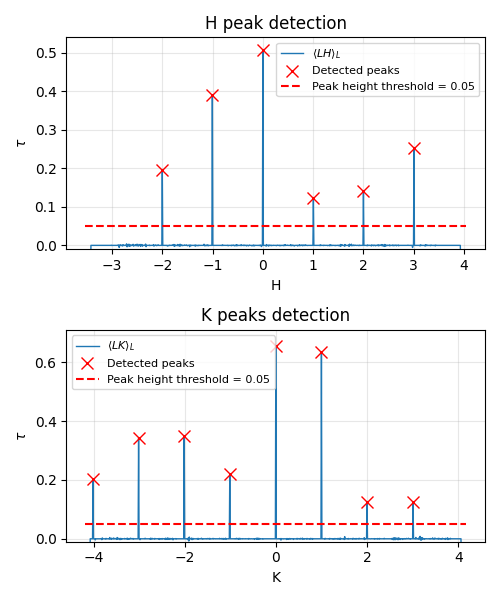

In [44]:
plt.figure(figsize=(5, 6))

# --- Plot HB_med ---
plt.subplot(2, 1, 1)
# plt.plot(BH_med, label='\left\langle LH \right\rangle_L', linewidth=1)
plt.plot(gridder.xaxis, BH_med, label=r'$\langle LH \rangle_L$', linewidth=1)

plt.plot(gridder.xaxis[H_peaks_med], BH_med[H_peaks_med], "rx", markersize=8, label='Detected peaks')


plt.hlines(y=min_peak_height, xmin=round(gridder.xaxis.min(), 2) - 0.1,
           xmax=round(gridder.xaxis.max(), 2) + 0.1, 
           colors='red', linestyles='--', lw=1.5, 
           label=f'Peak height threshold = {min_peak_height}')


# plt.hlines(y=0, xmin=round(gridder.xaxis.min(), 2), xmax=round(gridder.xaxis.max(), 2), 
#            colors='gray', linestyles=':', lw=0.8, alpha=0.6, label='Zero line')

plt.ylim(-0.01, None)
plt.xlabel('H')
plt.ylabel(r'$\tau$')
plt.title('H peaks detection')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)


# --- Plot HB_med ---
plt.subplot(2, 1, 2)
# plt.plot(BH_med, label='\left\langle LH \right\rangle_L', linewidth=1)
plt.plot(gridder.yaxis, BK_med, label=r'$\langle LK \rangle_L$', linewidth=1)

plt.plot(gridder.yaxis[K_peaks_med], BK_med[K_peaks_med], "rx", markersize=8, label='Detected peaks')


plt.hlines(y=min_peak_height, xmin=round(gridder.yaxis.min(), 2) - 0.1, 
                              xmax=round(gridder.yaxis.max(), 2) + 0.1, 
                              colors='red', linestyles='--', lw=1.5, 
                              label=f'Peak height threshold = {min_peak_height}')


# plt.hlines(y=0, xmin=round(gridder.xaxis.min(), 2), xmax=round(gridder.xaxis.max(), 2), 
#            colors='gray', linestyles=':', lw=0.8, alpha=0.6, label='Zero line')

plt.ylim(-0.01, None)
plt.xlabel('K')
plt.ylabel(r'$\tau$')
plt.title('K peaks detection')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

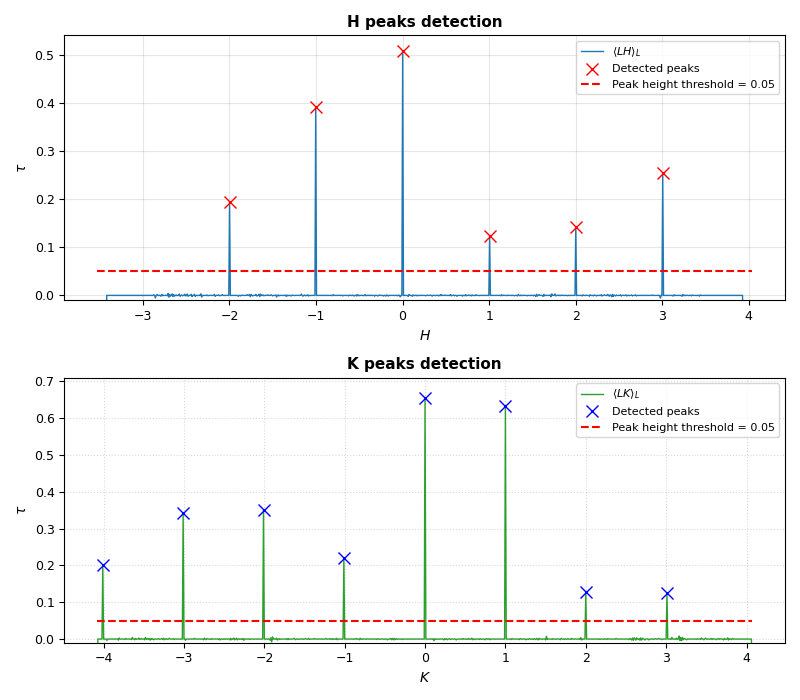

In [56]:
plt.figure(figsize=(8, 7))

# --- Plot H-projection ---
plt.subplot(2, 1, 1)
plt.plot(gridder.xaxis, BH_med, label=r'$\langle LH \rangle_L$', linewidth=1, color='C0')  # default blue
plt.plot(gridder.xaxis[H_peaks_med], BH_med[H_peaks_med], "rx", markersize=8, label='Detected peaks')

plt.hlines(y=min_peak_height, 
           xmin=round(gridder.xaxis.min(), 2) - 0.1,
           xmax=round(gridder.xaxis.max(), 2) + 0.1, 
           colors='red', linestyles='--', lw=1.5, 
           label=f'Peak height threshold = {min_peak_height}')

plt.ylim(-0.01, None)
plt.xlabel(r'$H$', fontweight='bold', fontsize=10)          # ← bold + larger
plt.ylabel(r'$\tau$', fontweight='bold', fontsize=10)        # ← bold + larger
plt.title('H peaks detection', fontsize=11, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Increase tick label font size
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)


# --- Plot K-projection (different color scheme) ---
plt.subplot(2, 1, 2)
# Use green/orange instead of blue/red for visual distinction
plt.plot(gridder.yaxis, BK_med, label=r'$\langle LK \rangle_L$', linewidth=1, color='C2')  # green
plt.plot(gridder.yaxis[K_peaks_med], BK_med[K_peaks_med], "bx", markersize=8, label='Detected peaks')  # magenta circles

plt.hlines(y=min_peak_height, 
           xmin=round(gridder.yaxis.min(), 2) , 
           xmax=round(gridder.yaxis.max(), 2) , 
           colors='red', linestyles='--', lw=1.5,    # ← orange dashed line
           label=f'Peak height threshold = {min_peak_height}')

plt.ylim(-0.01, None)
plt.xlabel(r'$K$', fontweight='bold', fontsize=10)
plt.ylabel(r'$\tau$', fontweight='bold', fontsize=10)
plt.title('K peaks detection', fontsize=11, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3, color='gray', linestyle=':')  # ← lighter grid

# Increase tick label font size
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)


plt.tight_layout()
plt.show()

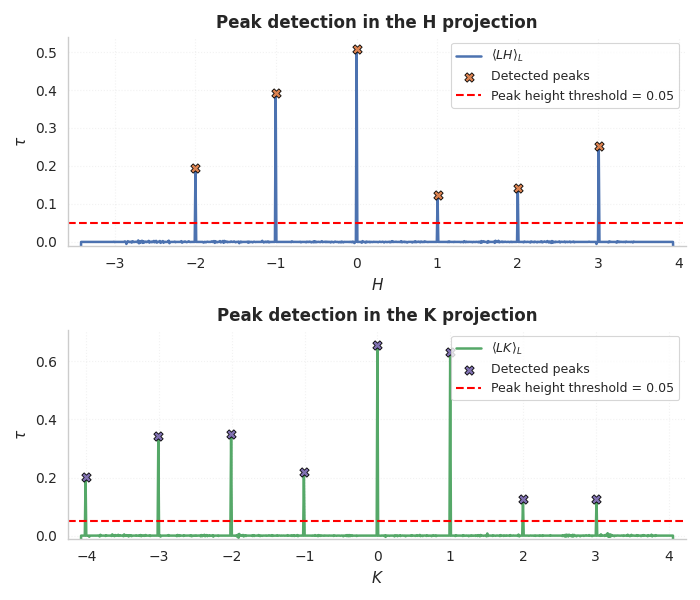

In [62]:
# Style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharey=False)

# Colors
h_line_color = "#4C72B0"   # blue
h_peak_color = "#DD8452"   # orange
k_line_color = "#55A868"   # green
k_peak_color = "#8172B2"   # purple
thr_color = "red"

# ---------- H projection ----------
ax = axes[0]
ax.plot(
    gridder.xaxis, BH_med,
    label=r'$\langle LH \rangle_L$',
    linewidth=1.8,
    color=h_line_color
)

ax.scatter(
    gridder.xaxis[H_peaks_med],
    BH_med[H_peaks_med],
    s=45,
    marker="X",
    facecolor=h_peak_color,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
    label="Detected peaks"
)

ax.axhline(
    y=min_peak_height,
    color=thr_color,
    linestyle="--",
    linewidth=1.5,
    label=f"Peak height threshold = {min_peak_height}"
)

ax.set_ylim(-0.01, None)
ax.set_xlabel(r"$H$")
ax.set_ylabel(r"$\tau$")
ax.set_title("Peak detection in the H projection")
ax.grid(True, alpha=0.25, linestyle=":")
ax.legend(loc="best", frameon=True)

# ---------- K projection ----------
ax = axes[1]
ax.plot(
    gridder.yaxis, BK_med,
    label=r'$\langle LK \rangle_L$',
    linewidth=1.8,
    color=k_line_color
)

ax.scatter(
    gridder.yaxis[K_peaks_med],
    BK_med[K_peaks_med],
    s=45,
    marker="X",
    facecolor=k_peak_color,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
    label="Detected peaks"
)

ax.axhline(
    y=min_peak_height,
    color=thr_color,
    linestyle="--",
    linewidth=1.5,
    label=f"Peak height threshold = {min_peak_height}"
)

ax.set_ylim(-0.01, None)
ax.set_xlabel(r"$K$")
ax.set_ylabel(r"$\tau$")
ax.set_title("Peak detection in the K projection")
ax.grid(True, alpha=0.25, linestyle=":")
ax.legend(loc="best", frameon=True)

# Small x-margins instead of manual rounded limits
for ax in axes:
    ax.margins(x=0.02)

plt.tight_layout()
plt.show()

In [39]:
load = False
if load:
    mask_filenm = f'P07_{Scan}_Mask.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...loading masks - {mask_filenm}\n')
    Mask = np.load(outfile).astype(bool, copy=False)
    print(f'\n...file {mask_filenm} loaded, done\n')
else:
    print('\n...preparing masks\n')
    Mask = xrd_geom.make_mask_fast(h[:], k[:], h_peak, k_peak, threshold=0.024)

# old threshold 0.15



...preparing masks



In [40]:
max_mask = read_plot.max_pxl_im(Mask)
max_imgs = read_plot.max_pxl_im(data)

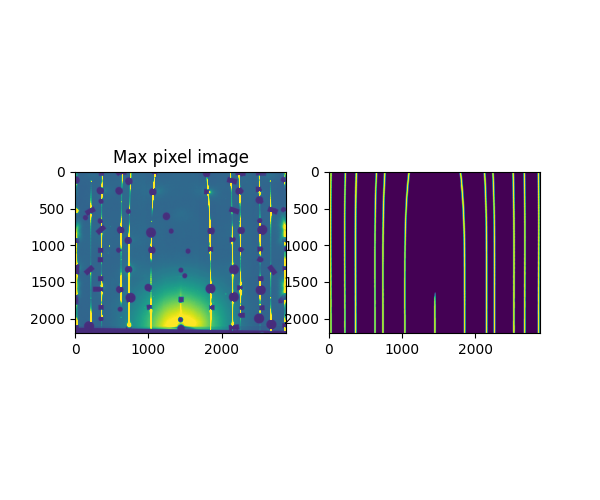

In [41]:
fig, ax = plt.subplot_mosaic([
    ['maxim', 'maxmsk']  ], figsize=(6, 5))
ax['maxim'].imshow(max_imgs, vmax=220)
ax['maxmsk'].imshow(max_mask, vmax=1)
ax['maxim'].set_title('Max pixel image')
plt.show()

(<Figure size 1000x600 with 3 Axes>,
 {'img': <Axes: label='img'>, 'mask': <Axes: label='mask'>})

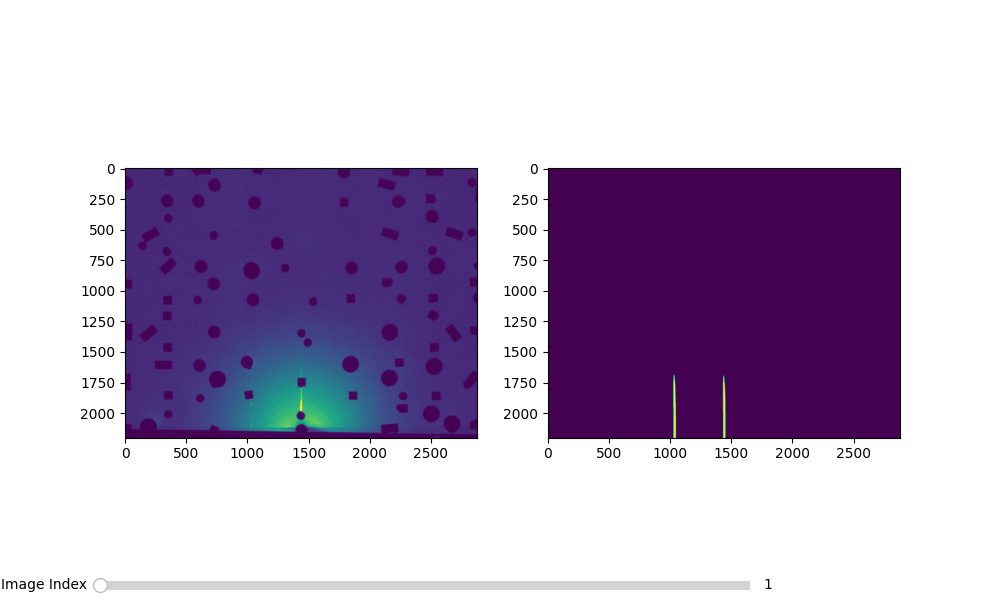

In [18]:
# 25
read_plot.image_mask_slider(data, Mask, vmax_im1 = 250, vmax_im2 = 1, fig_size=(10, 6))

In [63]:
maxINT_lk = np.nanmax(INT, axis=2)
maxINT_lh = np.nanmax(INT, axis=1)
maxINT_hk = np.nanmax(INT, axis=0)
grid_xaxis = gridder.xaxis
grid_yaxis = gridder.yaxis
grid_zaxis = gridder.zaxis

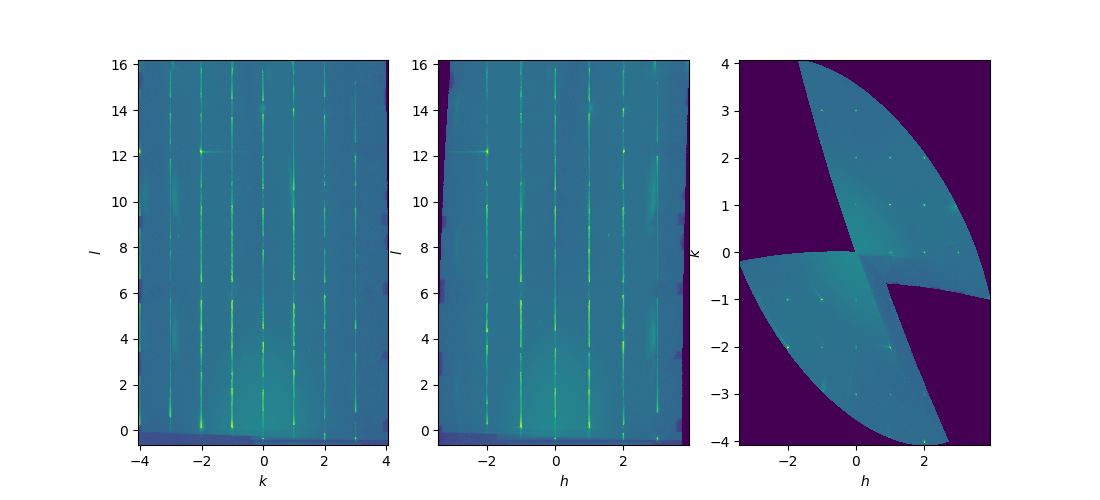

In [63]:
fig, ax = plt.subplot_mosaic([
    ['kl', 'hl', 'hk']  ], figsize=(11, 5))

ax['kl'].contourf(grid_yaxis, grid_zaxis, maxINT_lk, bins, extend='min', vmin=0, vmax=5)
ax['hl'].contourf(grid_xaxis, grid_zaxis, maxINT_lh, bins, extend='min', vmin=0, vmax=5)
ax['hk'].contourf(grid_xaxis, grid_yaxis, maxINT_hk, bins, extend='min', vmin=0, vmax=5)

ax['hl'].set_xlabel(r'$h$')
ax['hl'].set_ylabel(r'$l$')

ax['kl'].set_xlabel(r'$k$')
ax['kl'].set_ylabel(r'$l$')

ax['hk'].set_xlabel(r'$h$')
ax['hk'].set_ylabel(r'$k$')

plt.show()

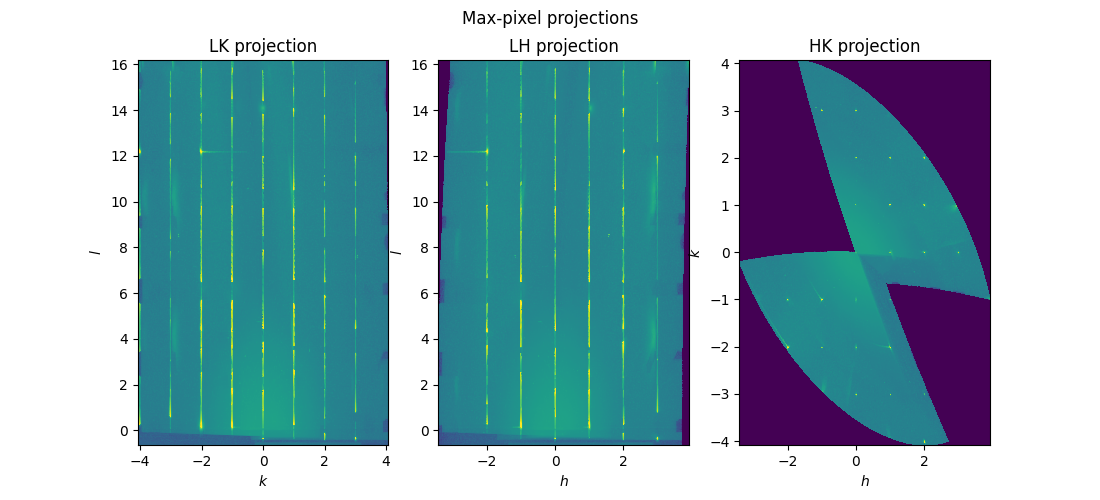

In [64]:
fig, ax = plt.subplot_mosaic([
    ['kl', 'hl', 'hk']  ], figsize=(11, 5))

fig.suptitle('Max-pixel projections')

ax['kl'].contourf(grid_yaxis, grid_zaxis, maxINT_lk, bins, extend='min', vmin=0, vmax=4)
ax['hl'].contourf(grid_xaxis, grid_zaxis, maxINT_lh, bins, extend='min', vmin=0, vmax=4)
ax['hk'].contourf(grid_xaxis, grid_yaxis, maxINT_hk, bins, extend='min', vmin=0, vmax=4)

ax['hl'].set_xlabel(r'$h$')
ax['hl'].set_ylabel(r'$l$')

ax['kl'].set_xlabel(r'$k$')
ax['kl'].set_ylabel(r'$l$')

ax['hk'].set_xlabel(r'$h$')
ax['hk'].set_ylabel(r'$k$')

ax['hl'].set_title(f"LH projection")
ax['kl'].set_title(f"LK projection")
ax['hk'].set_title(f"HK projection")


plt.show()

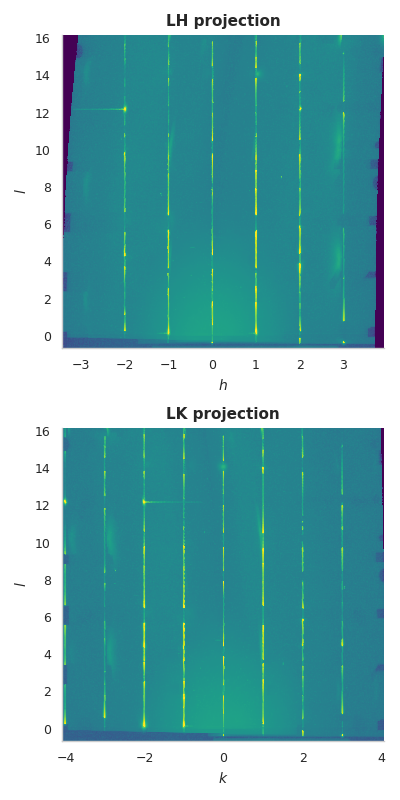

In [70]:
fig, ax = plt.subplot_mosaic([
    ['hl'],
    ['kl'],  
], figsize=(4, 8))

# fig.suptitle('Max-pixel projections', y=0.98, fontweight='bold', fontsize=12)

# --- LK projection (top) ---
cf_kl = ax['kl'].contourf(
    grid_yaxis, grid_zaxis, maxINT_lk, bins,
    extend='min', vmin=0, vmax=4, cmap='viridis'  # ← viridis colormap
)
ax['kl'].set_xlabel(r'$k$', fontweight='bold', fontsize=10)
ax['kl'].set_ylabel(r'$l$', fontweight='bold', fontsize=10)
ax['kl'].set_title("LK projection", fontsize=11, fontweight='bold')
ax['kl'].tick_params(labelsize=9)
# plt.colorbar(cf_kl, ax=ax['kl'], label='Intensity (a.u.)', shrink=0.85)  # ← colorbar

# --- LH projection (bottom) ---
cf_hl = ax['hl'].contourf(
    grid_xaxis, grid_zaxis, maxINT_lh, bins,
    extend='min', vmin=0, vmax=4, cmap='viridis'  # ← viridis colormap
)
ax['hl'].set_xlabel(r'$h$', fontweight='bold', fontsize=10)
ax['hl'].set_ylabel(r'$l$', fontweight='bold', fontsize=10)
ax['hl'].set_title("LH projection", fontsize=11, fontweight='bold')
ax['hl'].tick_params(labelsize=9)
# plt.colorbar(cf_hl, ax=ax['hl'], label='Intensity (a.u.)', shrink=0.85)  # ← colorbar

plt.tight_layout()
plt.show()

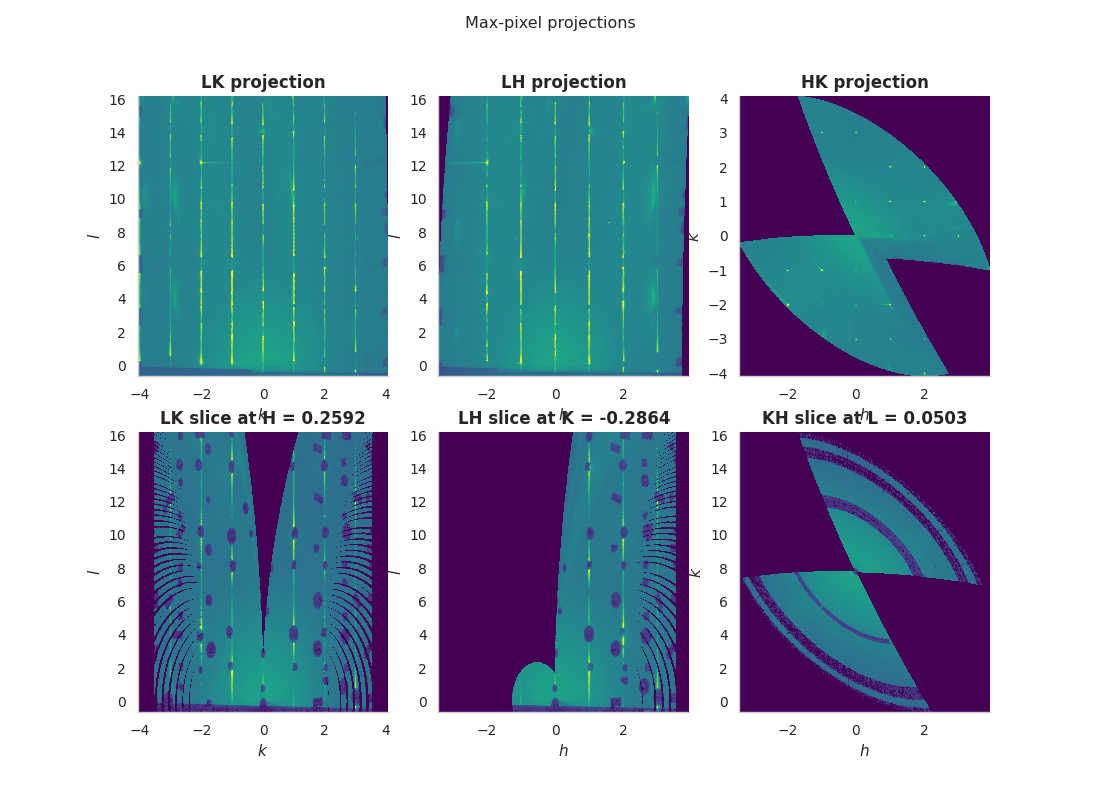

In [84]:
ik = 372
ih = 400
il = 33

fig, ax = plt.subplot_mosaic([
    ['kl', 'hl', 'hk',], ['slice_kl', 'slice_hl', 'slice_hk'] 
    ], figsize=(11, 8))

fig.suptitle('Max-pixel projections')

ax['kl'].contourf(grid_yaxis, grid_zaxis, maxINT_lk, bins, extend='min', vmin=0, vmax=4, cmap='viridis')
ax['hl'].contourf(grid_xaxis, grid_zaxis, maxINT_lh, bins, extend='min', vmin=0, vmax=4, cmap='viridis')
ax['hk'].contourf(grid_xaxis, grid_yaxis, maxINT_hk, bins, extend='min', vmin=0, vmax=4, cmap='viridis')

ax['hl'].set_xlabel(r'$h$')
ax['hl'].set_ylabel(r'$l$')

ax['kl'].set_xlabel(r'$k$')
ax['kl'].set_ylabel(r'$l$')

ax['hk'].set_xlabel(r'$h$')
ax['hk'].set_ylabel(r'$k$')

ax['hl'].set_title(f"LH projection")
ax['kl'].set_title(f"LK projection")
ax['hk'].set_title(f"HK projection")

ax['slice_kl'].contourf(grid_yaxis, grid_zaxis, INT[:, :, ik], bins, extend='min', vmin=0, vmax=4, cmap='viridis')
ax['slice_hl'].contourf(grid_xaxis, grid_zaxis, INT[:, ih, :], bins, extend='min', vmin=0, vmax=4, cmap='viridis')
ax['slice_hk'].contourf(grid_xaxis, grid_zaxis, INT[il, :, :], bins, extend='min', vmin=0, vmax=4, cmap='viridis')

ax['slice_hl'].set_title(f"LH slice at K = {grid_yaxis[ik]:.4f}")
ax['slice_kl'].set_title(f"LK slice at H = {grid_xaxis[ih]:.4f}")
ax['slice_hk'].set_title(f"KH slice at L = {grid_zaxis[il]:.4f}")


ax['slice_hl'].set_xlabel(r'$h$')
ax['slice_hl'].set_ylabel(r'$l$')

ax['slice_kl'].set_xlabel(r'$k$')
ax['slice_kl'].set_ylabel(r'$l$')

ax['slice_hk'].set_xlabel(r'$h$')
ax['slice_hk'].set_ylabel(r'$k$')


plt.show()

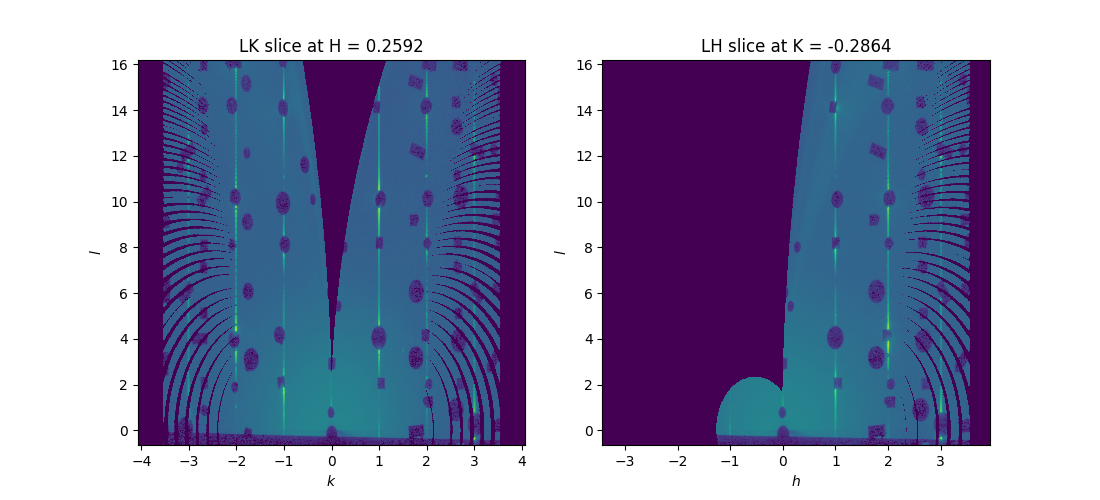

In [66]:
ik = 372
ih = 400


fig, ax = plt.subplot_mosaic([
    ['slice_kl', 'slice_hl']  ], figsize=(11, 5))

ax['slice_kl'].contourf(grid_yaxis, grid_zaxis, INT[:, :, 372], bins, extend='min', vmin=0, vmax=5)
ax['slice_hl'].contourf(grid_xaxis, grid_zaxis, INT[:, 400, :], bins, extend='min', vmin=0, vmax=5)

ax['slice_hl'].set_title(f"LH slice at K = {grid_yaxis[ik]:.4f}")
ax['slice_kl'].set_title(f"LK slice at H = {grid_xaxis[ih]:.4f}")


ax['slice_hl'].set_xlabel(r'$h$')
ax['slice_hl'].set_ylabel(r'$l$')

ax['slice_kl'].set_xlabel(r'$k$')
ax['slice_kl'].set_ylabel(r'$l$')


plt.show()

## Beamstops treatment 

In [71]:
median_data = np.median(data, axis=0)

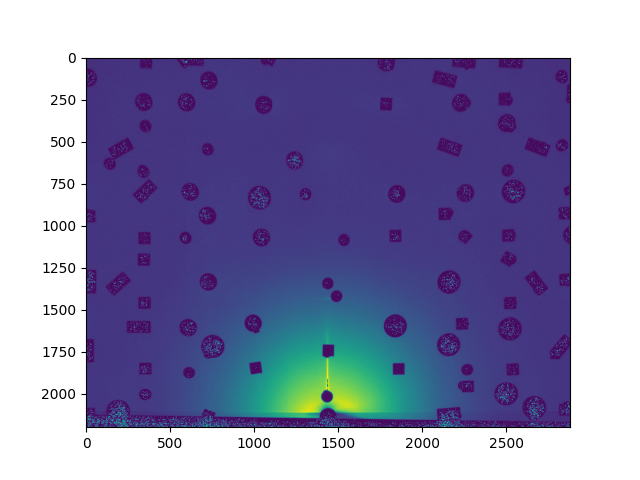

In [72]:
plt.figure()
plt.imshow(cv.medianBlur(median_data.astype(np.uint8), 3), vmin=0, vmax=200)
plt.show()

In [73]:
median_data_clipped = np.clip(median_data, 0, None)

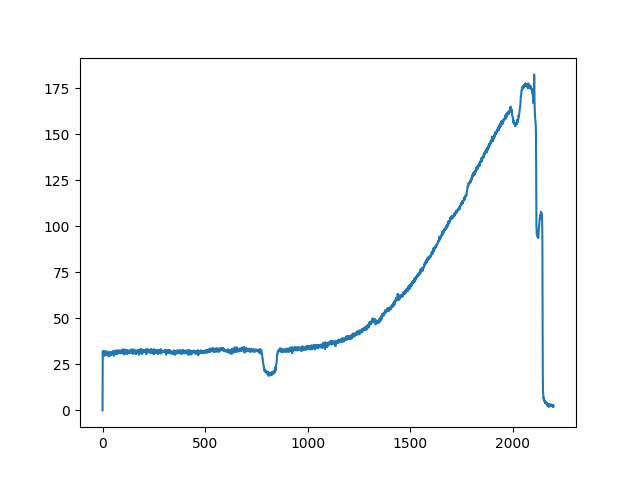

In [74]:
plt.figure()
plt.plot(np.mean(median_data_clipped[:, 1287: 1410], axis=1))
plt.show()

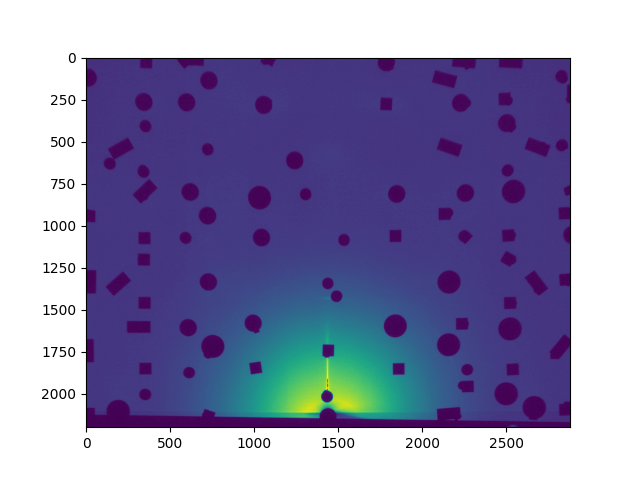

In [75]:
plt.figure()
plt.imshow(cv.medianBlur(median_data_clipped.astype(np.uint8), 3), vmin=0, vmax=200)
plt.show()

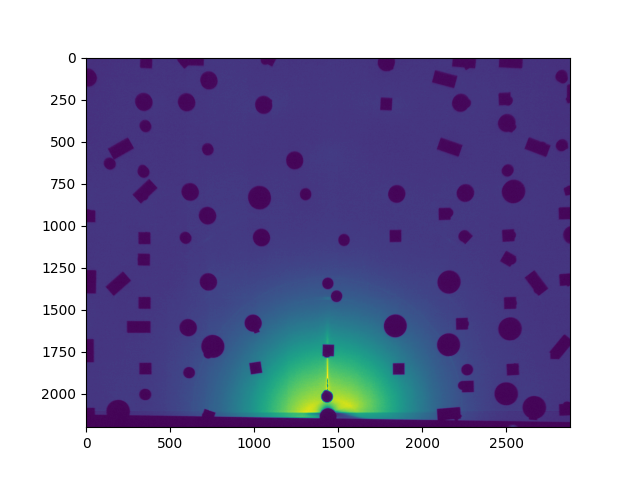

In [76]:
plt.figure()
plt.imshow(cv.GaussianBlur(median_data_clipped.astype(np.uint8), (3,3), 0), vmin=0, vmax=200)
plt.show()

In [77]:
med_test = cv.medianBlur(median_data_clipped.astype(np.uint8), 7)

In [78]:
med_test[med_test<10] = 0

In [79]:
inverted_img = np.where(med_test < 17, 255, 0)#.astype(np.uint8)

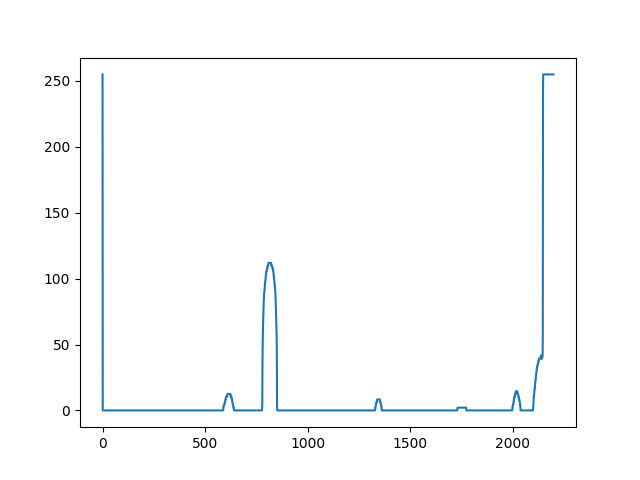

In [80]:
plt.figure()
plt.plot(np.mean(inverted_img[:, 1287: 1410], axis=1))
plt.show()

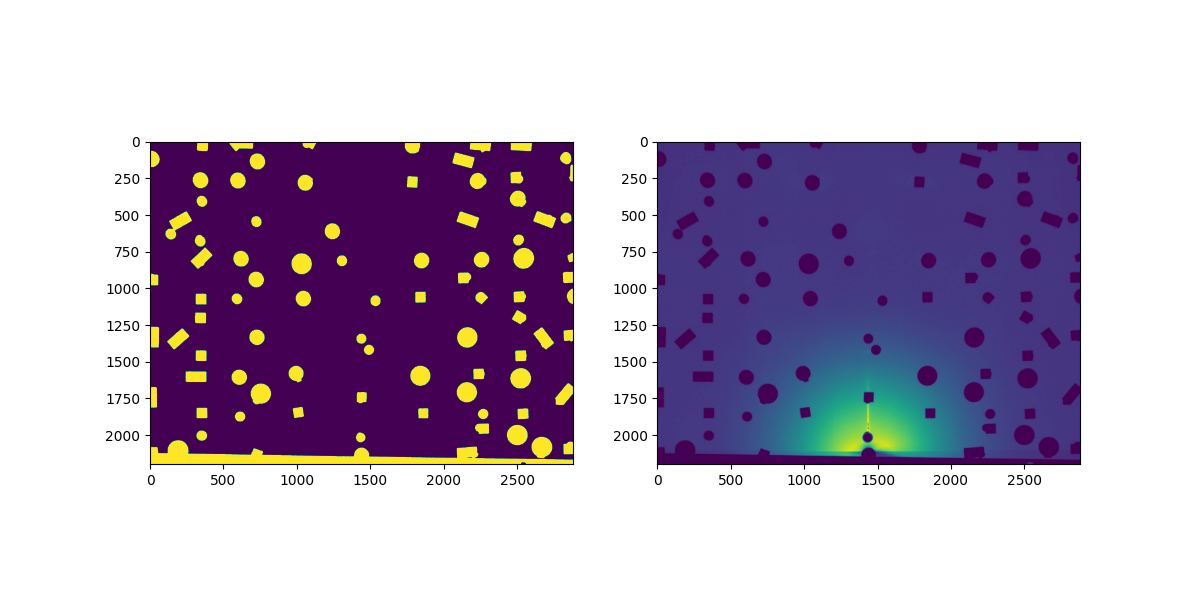

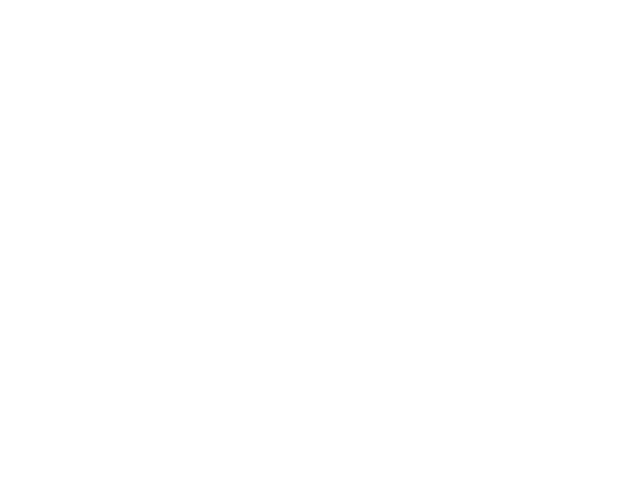

In [81]:
plt.clf()
plt.figure()

fig, ax = plt.subplots(nrows=1, ncols=2,
                                    figsize=(12, 6))

ax[0].imshow(inverted_img , vmin=0, vmax=200)
ax[1].imshow(med_test , vmin=0, vmax=200)
plt.show()

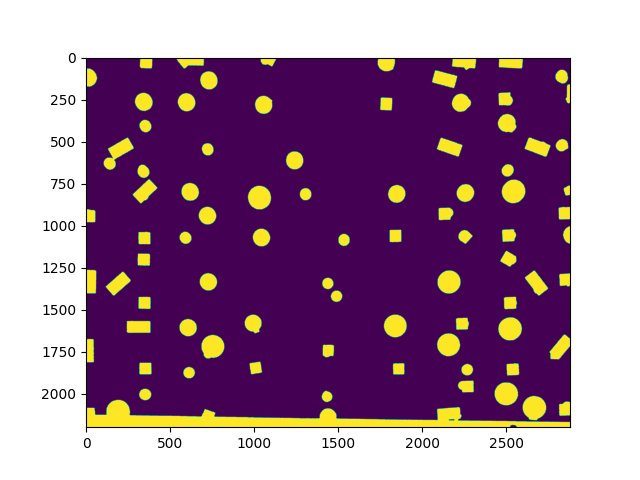

In [83]:
plt.figure()
plt.imshow(inverted_img, vmin=0, vmax=250)
plt.show()

## Saving calculated results

In [85]:
# save adjusted theta_ 

save_theta = True 
if save_theta:
    mask_filenm = f'{Scan}_theta_adjusted.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...saving theta arr - {mask_filenm}\n')
    np.save(outfile, theta_eff)
    print('\ndone \n')


...saving theta arr - pure_al2o3_00001_theta_adjusted.npy


done 



In [86]:
save_hkl = True
if save_hkl:
    mask_filenm = f'{Scan}_h_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...saving arr - {mask_filenm}\n')
    np.save(outfile, h)
    print(f'\n {mask_filenm} saving \ndone \n ')

    mask_filenm = f'{Scan}_k_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...saving arr - {mask_filenm}\n')
    np.save(outfile, k)
    print(f'\n {mask_filenm} saving \ndone \n ')

    mask_filenm = f'{Scan}_l_arr.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...saving arr - {mask_filenm}\n')
    np.save(outfile, l)
    print(f'\n {mask_filenm} saving \ndone \n ')
    
else:
    print('\n Masks saved already! \n')


...saving arr - pure_al2o3_00001_h_arr.npy


 pure_al2o3_00001_h_arr.npy saving 
done 
 

...saving arr - pure_al2o3_00001_k_arr.npy


 pure_al2o3_00001_k_arr.npy saving 
done 
 

...saving arr - pure_al2o3_00001_l_arr.npy


 pure_al2o3_00001_l_arr.npy saving 
done 
 


In [42]:
#save masks
save = True
if save:
    mask_filenm = f'P07_{Scan}_Mask.npy'
    outfile = OutputDir + f'{mask_filenm}'
    print(f'\n...saving masks - {mask_filenm}\n')
    np.save(outfile, Mask)
    print('\n done \n')
else:
    print('\n Masks saved already! \n')


...saving masks - P07_pure_al2o3_00001_Mask_024.npy


 done 



In [84]:
#saving 

mask_filenm = f'{Scan}_detected_beamstops.npy'
outfile = '/asap3/petra3/gpfs/p07/2022/data/11016526/processed/processed_data/' + f'{mask_filenm}'
    
print(f'\n...saving masks - {mask_filenm}\n')
np.save(outfile, inverted_img)
print(f'\nsaved masks - {mask_filenm}\n')


...saving masks - pure_al2o3_00001_detected_beamstops.npy


saved masks - pure_al2o3_00001_detected_beamstops.npy

